## Network Intrusion Detection System using Machine Learning

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import joblib

### Data Loading

In [9]:
path = "../data/*.csv"

files = glob.glob(path)

df_list = []

for file in files:
    data = pd.read_csv(file)
    data.columns = data.columns.str.strip()
    df_list.append(data)

df = pd.concat(df_list, ignore_index=True)

print(df.shape)
df.head()


(2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Sample 20,000 Rows

In [10]:
df = df.sample(20000, random_state=42)
print(df.shape)

(20000, 79)


### Data Cleaning

#### Remove useless columns.

In [11]:
cols_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

#### Fix invalid values.

In [12]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

### Label Encoding

#### Convert attack labels to numbers

In [13]:
le = LabelEncoder()

df["Label"] = le.fit_transform(df["Label"])

#### Check classes

In [14]:
print(le.classes_)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'PortScan' 'SSH-Patator'
 'Web Attack � Brute Force' 'Web Attack � XSS']


### Exploratory Data Analysis (EDA)

#### Dataset overview

In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 19975 entries, 746827 to 609904
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             19975 non-null  int64  
 1   Flow Duration                19975 non-null  int64  
 2   Total Fwd Packets            19975 non-null  int64  
 3   Total Backward Packets       19975 non-null  int64  
 4   Total Length of Fwd Packets  19975 non-null  int64  
 5   Total Length of Bwd Packets  19975 non-null  int64  
 6   Fwd Packet Length Max        19975 non-null  int64  
 7   Fwd Packet Length Min        19975 non-null  int64  
 8   Fwd Packet Length Mean       19975 non-null  float64
 9   Fwd Packet Length Std        19975 non-null  float64
 10  Bwd Packet Length Max        19975 non-null  int64  
 11  Bwd Packet Length Min        19975 non-null  int64  
 12  Bwd Packet Length Mean       19975 non-null  float64
 13  Bwd Packet Leng

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,19975.000000,1.997500e+04,19975.000000,19975.000000,19975.000000,1.997500e+04,19975.000000,19975.000000,19975.000000,19975.000000,...,19975.000000,1.997500e+04,1.997500e+04,1.997500e+04,1.997500e+04,1.997500e+04,1.997500e+04,1.997500e+04,1.997500e+04,19975.000000
mean,7989.232190,1.462721e+07,6.346283,6.190488,520.248611,6.833882e+03,209.013166,18.644205,58.176729,68.584589,...,26.063980,7.789615e+04,3.828963e+04,1.442501e+05,5.696408e+04,8.138523e+06,5.086236e+05,8.519543e+06,7.734842e+06,0.934768
std,18253.397013,3.352123e+07,74.829511,84.259712,2971.063219,1.885359e+05,728.692803,56.742457,185.624368,279.304490,...,6.573331,5.398140e+05,3.033267e+05,8.284015e+05,4.955061e+05,2.331761e+07,4.673944e+06,2.409434e+07,2.302783e+07,2.168228
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,53.000000,1.580000e+02,2.000000,1.000000,12.000000,4.000000e+00,6.000000,0.000000,6.000000,0.000000,...,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,80.000000,3.129400e+04,2.000000,2.000000,62.000000,1.240000e+02,37.000000,2.000000,34.000000,0.000000,...,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,443.000000,2.811413e+06,5.000000,4.000000,188.000000,4.790000e+02,80.500000,36.000000,50.000000,25.195238,...,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
max,65481.000000,1.199994e+08,9449.000000,10063.000000,153145.000000,2.340090e+07,23360.000000,1983.000000,4640.757576,6429.190773,...,56.000000,1.500000e+07,9.328036e+06,2.650000e+07,1.500000e+07,1.200000e+08,6.680000e+07,1.200000e+08,1.200000e+08,11.000000


#### Attack distribution

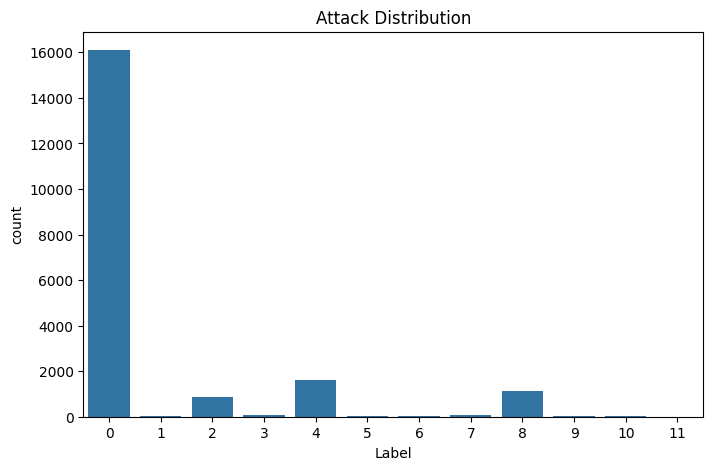

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["Label"])
plt.title("Attack Distribution")
plt.show()

### Correlation Heatmap

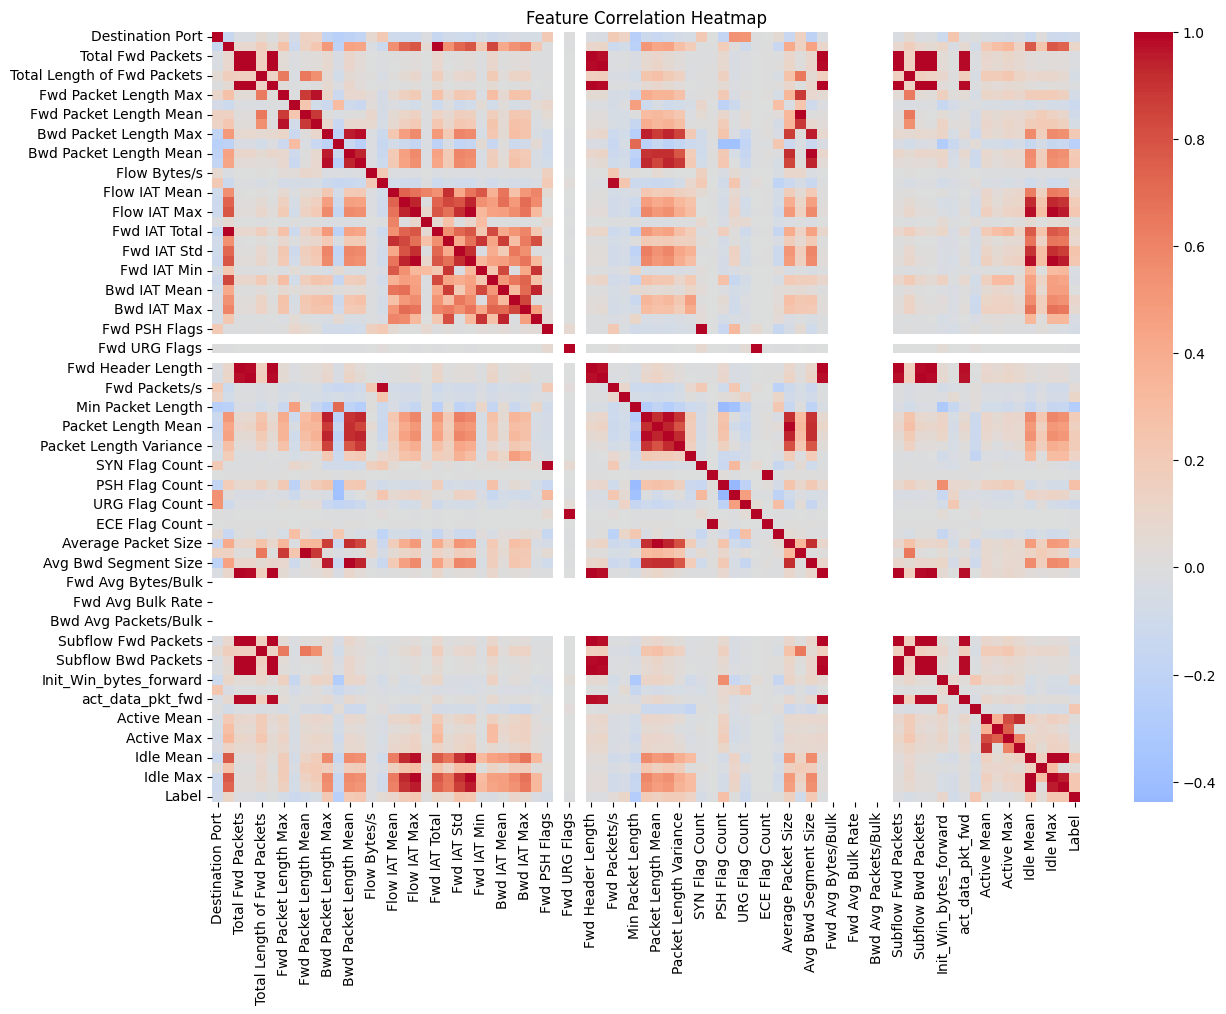

In [17]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Feature / Target Split

In [18]:
X = df.drop("Label", axis=1)
y = df["Label"]

### Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Feature Scaling

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Define 5 Models

In [21]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(n_estimators=100),

    "SVM":
        SVC(),

    "XGBoost":
        XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

}

### Train Models

In [22]:
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted")
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    results.append([name, acc, prec, rec, f1])

    print(name)
    print(classification_report(y_test, preds))

e:\pp_venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\pp_venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\pp_venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\pp_venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMet

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3220
           1       0.00      0.00      0.00         4
           2       0.97      0.97      0.97       175
           3       0.83      0.77      0.80        13
           4       0.91      0.95      0.93       320
           5       1.00      0.67      0.80         9
           6       1.00      0.67      0.80         9
           7       0.50      0.42      0.45        12
           8       0.80      1.00      0.89       222
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         2

    accuracy                           0.96      3995
   macro avg       0.58      0.53      0.55      3995
weighted avg       0.96      0.96      0.96      3995

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00 

e:\pp_venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\pp_venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\pp_venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\pp_venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMet

SVM
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3220
           1       0.00      0.00      0.00         4
           2       0.98      0.82      0.89       175
           3       1.00      0.54      0.70        13
           4       0.99      0.86      0.92       320
           5       1.00      0.67      0.80         9
           6       1.00      0.44      0.62         9
           7       0.00      0.00      0.00        12
           8       0.78      1.00      0.88       222
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         2

    accuracy                           0.96      3995
   macro avg       0.56      0.44      0.48      3995
weighted avg       0.95      0.96      0.95      3995

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3220
           1

### Model Comparison Table

In [23]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.963955,0.962888,0.963955,0.962552
1,Decision Tree,0.996496,0.996521,0.996496,0.996422
2,Random Forest,0.995995,0.995501,0.995995,0.995683
3,SVM,0.955194,0.951936,0.955194,0.951588
4,XGBoost,0.996746,0.996479,0.996746,0.996592


### Model Comparison Visualization

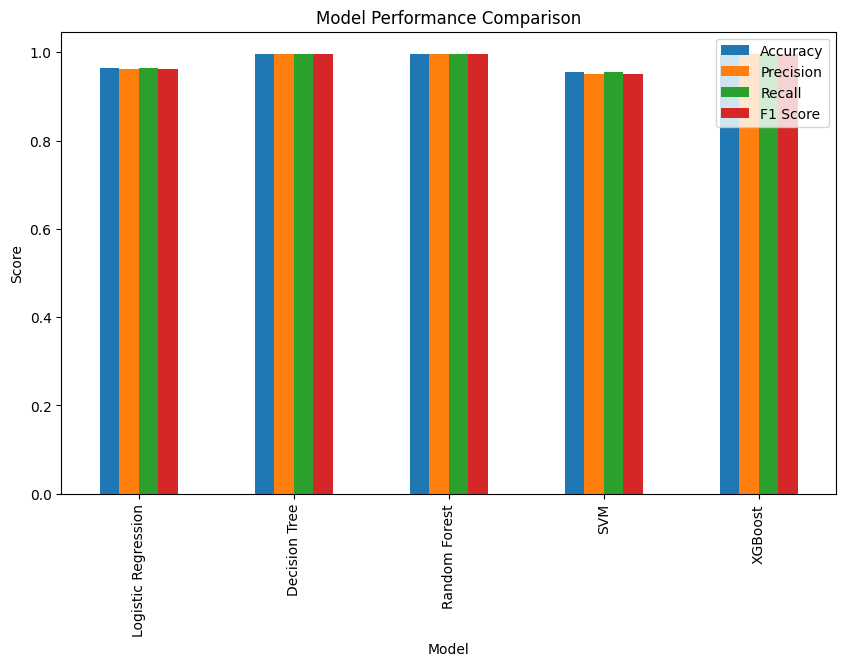

In [24]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

### Confusion Matrix For Each Model

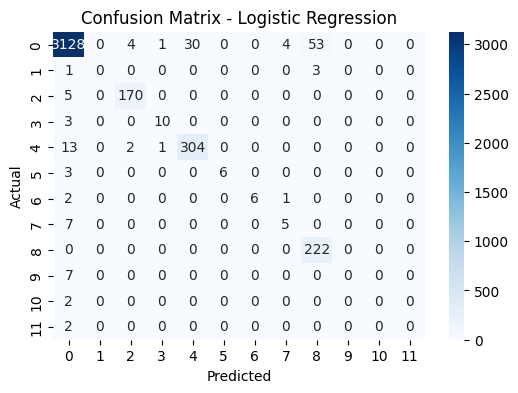

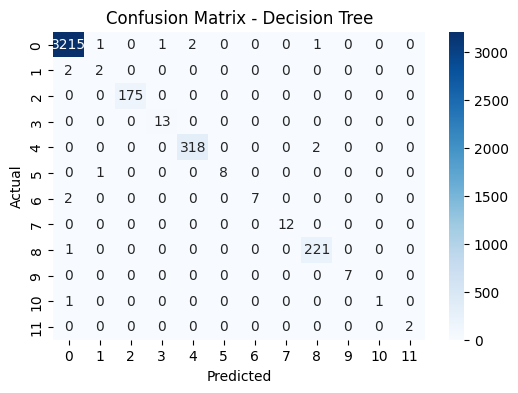

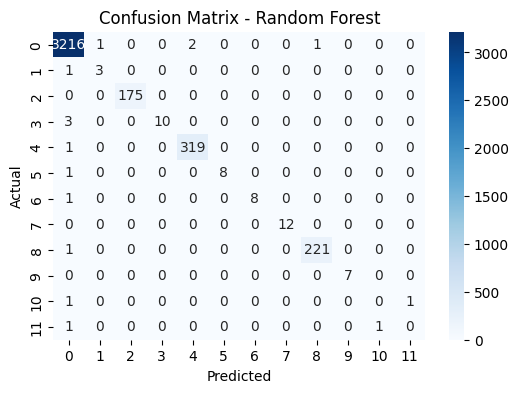

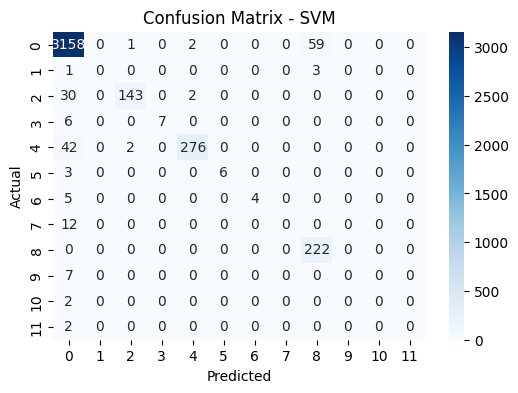

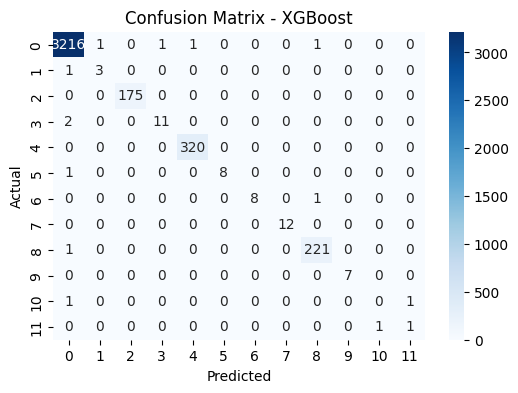

In [25]:
for name, model in models.items():

    preds = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### Feature Importance (Random Forest)

In [26]:
rf = models["Random Forest"]

importances = rf.feature_importances_

feature_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_imp = feature_imp.sort_values(
    by="Importance",
    ascending=False
).head(20)

#### Visualization

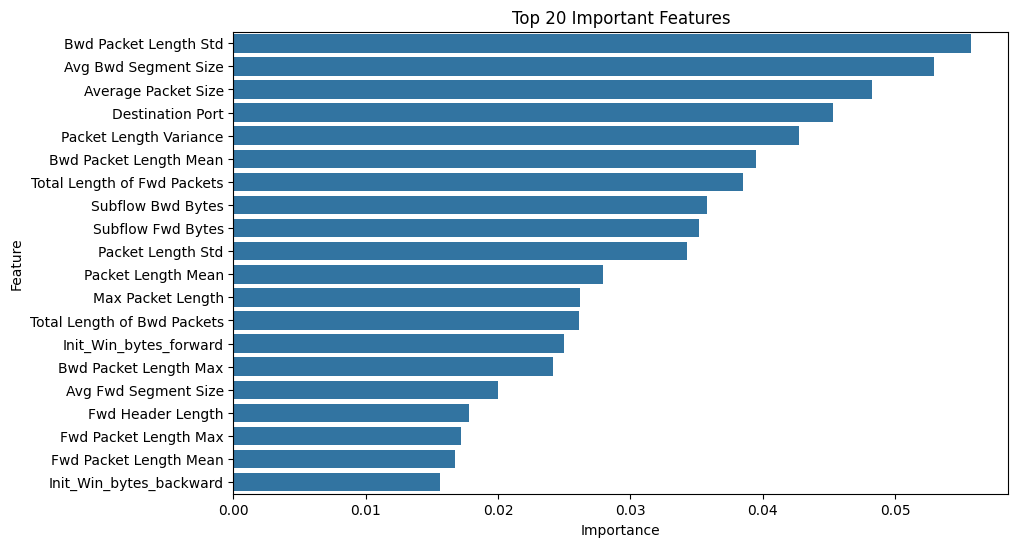

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_imp
)

plt.title("Top 20 Important Features")
plt.show()

### Best Model Selection

In [28]:
best_model = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print(best_model)

Model         XGBoost
Accuracy     0.996746
Precision    0.996479
Recall       0.996746
F1 Score     0.996592
Name: 4, dtype: object


### Save Model for FastAPI

In [29]:
best_model_name = best_model["Model"]

model = models[best_model_name]

joblib.dump(model, "intrusion_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved")

Model saved


### Example Prediction

In [30]:
sample = X_test.iloc[0:1]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("Predicted class:", prediction)

Predicted class: [0]
